# Notebook 3: Training the Neural Surrogate — Sum vs Attentive Message Passing

This notebook trains and compares two encoder variants on the birth-death CRN:

- **Run 1** (`birth_death_sum`): plain sum-aggregation message passing (baseline).
- **Run 2** (`birth_death_attentive`): attention-weighted message passing.

Both runs share the same training data, loss function, and all other hyperparameters.
The only difference is `EncoderConfig.use_attention`.

## Structure

1. **Configuration** — shared hyperparameters and per-run encoder configs.
2. **Training data** — M=16 SSA trajectories per item, shared across both runs.
3. **Run 1** — sum-aggregation encoder, trained with W&B logging.
4. **Run 2** — attentive encoder, trained with W&B logging.
5. **Training curve comparison** — side-by-side loss curves.
6. **Post-training evaluation** — mean/variance vs Gillespie ground truth for both models.

> **Scale note**: 30 epochs, 60 train items, d_model=32 — increase for real experiments.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
torch.manual_seed(42)
np.random.seed(42)

## 1. Configuration

Shared hyperparameters used by both runs. The only field that differs between runs
is `use_attention` in `EncoderConfig`, which selects between `SumMessagePassingLayer`
and `AttentiveMessagePassingLayer`.

In [2]:
from crn_surrogate.configs.model_config import ModelConfig, EncoderConfig, SDEConfig
from crn_surrogate.configs.training_config import TrainingConfig, SchedulerType
from crn_surrogate.crn.examples import birth_death

# ── CRN ────────────────────────────────────────────────────────────────────────
crn = birth_death(k_birth=2.0, k_death=0.5)   # stationary mean = variance = 4

# ── SDE config (shared — same architecture for both runs) ──────────────────────
sde_config = SDEConfig.from_crn(crn, d_model=32, d_hidden=64, clip_state=True)

# ── Encoder configs — one per run ──────────────────────────────────────────────
encoder_config_sum = EncoderConfig(d_model=32, n_layers=2, use_attention=False)
encoder_config_att = EncoderConfig(d_model=32, n_layers=2, use_attention=True)

# ── Training config (shared — only wandb_run_name differs) ────────────────────
_train_kwargs = dict(
    lr=3e-3,
    max_epochs=30,
    batch_size=4,
    n_sde_samples=8,
    n_ssa_samples=16,
    dt=0.2,
    val_every=5,
    grad_clip_norm=1.0,
    scheduler_type=SchedulerType.REDUCE_ON_PLATEAU,
    use_wandb=True,
    wandb_project="crn_surrogate",
)

train_config_sum = TrainingConfig(**_train_kwargs, wandb_run_name="birth_death_sum")
train_config_att = TrainingConfig(**_train_kwargs, wandb_run_name="birth_death_attentive")

print(f"CRN:           {crn}")
print(f"SDE:           {sde_config}")
print(f"Encoder (sum): {encoder_config_sum}")
print(f"Encoder (att): {encoder_config_att}")
print(f"Training:      {train_config_sum}")

CRN:           CRN(n_species=1, n_reactions=2, species=('A',))
SDE:           SDEConfig(d_model=32, d_hidden=64, n_noise_channels=2, clip_state=True)
Encoder (sum): EncoderConfig(d_model=32, n_layers=2, n_propensity_types=4, max_propensity_params=4)
Encoder (att): EncoderConfig(d_model=32, n_layers=2, n_propensity_types=4, max_propensity_params=4)
Training:      TrainingConfig(lr=0.003, max_epochs=30, batch_size=4, dt=0.2, n_ssa_samples=16, scheduler=reduce_on_plateau, use_wandb=True)


## 2. Generate Training and Validation Data

Each item holds M=16 independent SSA trajectories. The variance-matching loss computes
`Var_true[X(t)]` from these M runs, giving G_θ a gradient signal to learn stochasticity.

The same dataset is shared between Run 1 and Run 2.

Train: 60 items × 16 SSA runs = 960 trajectories
Val:   20 items × 16 SSA runs = 320 trajectories


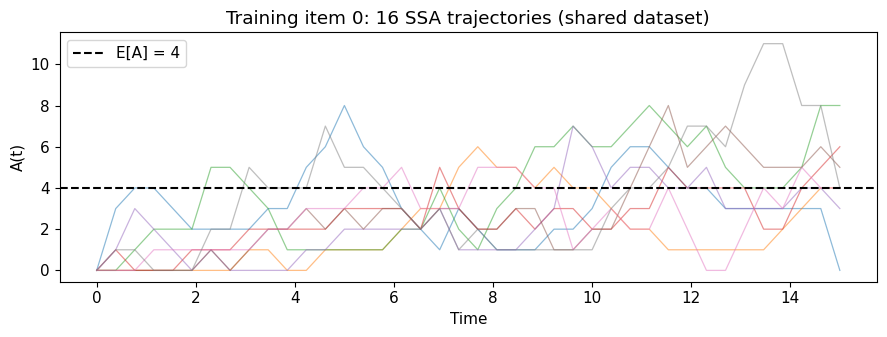

In [3]:
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem

T_MAX = 15.0
N_GRID = 40
M = train_config_sum.n_ssa_samples
time_grid = torch.linspace(0.0, T_MAX, N_GRID)
ssa = GillespieSSA()
init_state = torch.tensor([0.0])
crn_repr = crn_to_tensor_repr(crn)

N_TRAIN, N_VAL = 60, 20

def make_items(n: int) -> list[TrajectoryItem]:
    items = []
    for _ in range(n):
        trajs = []
        for _ in range(M):
            traj = ssa.simulate(
                stoichiometry=crn.stoichiometry_matrix,
                propensity_fn=crn.evaluate_propensities,
                initial_state=init_state.clone(),
                t_max=T_MAX,
            )
            trajs.append(interpolate_to_grid(traj.times, traj.states, time_grid))
        items.append(TrajectoryItem(
            crn_repr=crn_repr,
            initial_state=init_state.clone(),
            trajectories=torch.stack(trajs),
            times=time_grid,
        ))
    return items

train_dataset = CRNTrajectoryDataset(make_items(N_TRAIN))
val_dataset   = CRNTrajectoryDataset(make_items(N_VAL))

print(f'Train: {len(train_dataset)} items × {M} SSA runs = {len(train_dataset) * M} trajectories')
print(f'Val:   {len(val_dataset)} items × {M} SSA runs = {len(val_dataset) * M} trajectories')

fig, ax = plt.subplots(figsize=(9, 3.5))
item = train_dataset[0]
for m in range(min(8, M)):
    ax.plot(time_grid.numpy(), item.trajectories[m, :, 0].numpy(), alpha=0.5, linewidth=0.9)
ax.axhline(2.0 / 0.5, color='black', linestyle='--', linewidth=1.5, label='E[A] = 4')
ax.set_xlabel('Time'); ax.set_ylabel('A(t)')
ax.set_title(f'Training item 0: {M} SSA trajectories (shared dataset)')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Run 1 — Sum Message Passing

Baseline: plain MLP + sum aggregation at each message-passing round (`use_attention=False`).
W&B run name: `birth_death_sum`.

In [4]:
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE

encoder_sum = BipartiteGNNEncoder(encoder_config_sum)
sde_sum     = CRNNeuralSDE(sde_config, n_species=1)

n_enc_sum = sum(p.numel() for p in encoder_sum.parameters())
n_sde     = sum(p.numel() for p in sde_sum.parameters())
print(f'Encoder params (sum): {n_enc_sum:,}')
print(f'SDE params:           {n_sde:,}')
print(f'n_noise_channels = {sde_config.n_noise_channels}  (= n_reactions = {crn.n_reactions})')

Encoder params (sum): 11,384
SDE params:           9,161
n_noise_channels = 2  (= n_reactions = 2)


### 3a. Train

`CombinedTrajectoryLoss` combines `MeanMatchingLoss` (drift) and `VarianceMatchingLoss` (diffusion).
The Trainer iterates over batches, uses ReduceLROnPlateau, and returns a `TrainingResult`.

In [5]:
from crn_surrogate.training.losses import CombinedTrajectoryLoss
from crn_surrogate.training.trainer import Trainer

loss_fn = CombinedTrajectoryLoss(var_weight=0.5)
model_config_sum = ModelConfig(encoder=encoder_config_sum, sde=sde_config)

trainer_sum = Trainer(encoder_sum, sde_sum, model_config_sum, train_config_sum, loss_fn=loss_fn)
result_sum = trainer_sum.train(train_dataset, val_dataset)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jan/.netrc.
wandb: Currently logged in as: jan-mikelson (jan-mikelson-independent) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch    1 | train=4.3440


Epoch    2 | train=0.8021


Epoch    3 | train=1.2220


Epoch    4 | train=0.8152


...

Epoch   27 | train=0.7197


Epoch   28 | train=0.7648


Epoch   29 | train=0.7632


Epoch   30 | train=0.7529 | val=0.8221


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
timing/backward_mean_s,█▆▂▁▂▁▂▁▂▁▁▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▂▁▁▁
timing/backward_total_s,█▆▂▁▂▁▂▁▂▁▁▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▂▁▁▁
timing/forward_mean_s,▁█▄▄▄▄▄▄▄▄▃▄▄▃▃▄▃▇▃▃▂▄▃▄▄▃▅▃▄▃
timing/forward_total_s,▁█▄▄▄▄▄▄▄▄▃▄▄▃▃▄▃▇▃▃▂▄▃▄▄▃▅▃▄▃
train_loss,█▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▁▄▁▂█
epoch,30
timing/backward_mean_s,1.0943
timing/backward_total_s,16.41449
timing/forward_mean_s,0.72991


## 4. Run 2 — Attentive Message Passing

Attention-weighted aggregation: query/key projections compute per-incoming-message weights
so the network can learn to suppress irrelevant messages (`use_attention=True`).
W&B run name: `birth_death_attentive`.

In [6]:
encoder_att = BipartiteGNNEncoder(encoder_config_att)
sde_att     = CRNNeuralSDE(sde_config, n_species=1)

n_enc_att = sum(p.numel() for p in encoder_att.parameters())
print(f'Encoder params (attentive): {n_enc_att:,}')
print(f'SDE params:                 {n_sde:,}')
print(f'Extra params from attention: +{n_enc_att - n_enc_sum:,}')

Encoder params (attentive): 13,496
SDE params:                 9,161
Extra params from attention: +2,112


### 4a. Train

In [7]:
model_config_att = ModelConfig(encoder=encoder_config_att, sde=sde_config)

trainer_att = Trainer(encoder_att, sde_att, model_config_att, train_config_att, loss_fn=loss_fn)
result_att = trainer_att.train(train_dataset, val_dataset)

Epoch    1 | train=81.0576


Epoch    2 | train=0.8756


Epoch    3 | train=0.8463


Epoch    4 | train=0.8391


Epoch    5 | train=0.7554 | val=0.6920


...

Epoch   27 | train=0.8111


Epoch   28 | train=0.7630


Epoch   29 | train=0.8092


Epoch   30 | train=0.7446 | val=0.7556


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
timing/backward_mean_s,▇▅▄█▂▄▆▆█▃▄▃▃▄▃▂▃▃▃▂▁▂▃▃▁▁▁▁▁▁
timing/backward_total_s,▇▅▄█▂▄▆▆█▃▄▃▃▄▃▂▃▃▃▂▁▂▃▃▁▁▁▁▁▁
timing/forward_mean_s,▇▅▂▇▂▅▆██▃▃▃▃▃▃▃▃▂▂▃▁▂▃▂▂▁▁▁▁▁
timing/forward_total_s,▇▅▂▇▂▅▆██▃▃▃▃▃▃▃▃▂▂▃▁▂▃▂▂▁▁▁▁▁
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▃█▂▁▄▆
epoch,30
timing/backward_mean_s,1.08286
timing/backward_total_s,16.24296
timing/forward_mean_s,0.72075


## 5. Training Curve Comparison

Side-by-side loss curves for sum (blue) and attentive (red) aggregation.
The W&B dashboard (`crn_surrogate` project) shows both runs grouped together
for interactive comparison across all logged metrics.

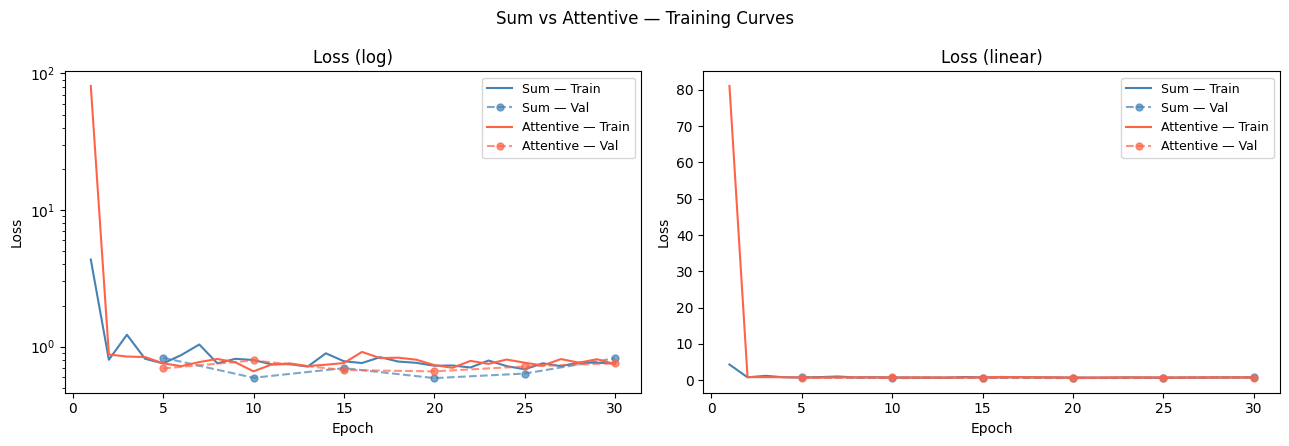

Run 1 (sum)       — final train: 0.7529  best val: 0.5883
Run 2 (attentive) — final train: 0.7446  best val: 0.6593


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, yscale in zip(axes, ['log', 'linear']):
    ax.plot(range(1, len(result_sum.train_losses) + 1), result_sum.train_losses,
            color='steelblue', label='Sum — Train')
    ax.plot(result_sum.val_epochs, result_sum.val_losses,
            'o--', color='steelblue', markersize=5, alpha=0.7, label='Sum — Val')
    ax.plot(range(1, len(result_att.train_losses) + 1), result_att.train_losses,
            color='tomato', label='Attentive — Train')
    ax.plot(result_att.val_epochs, result_att.val_losses,
            'o--', color='tomato', markersize=5, alpha=0.7, label='Attentive — Val')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'Loss ({yscale})')
    ax.set_yscale(yscale); ax.legend(fontsize=9)

plt.suptitle('Sum vs Attentive — Training Curves', fontsize=12)
plt.tight_layout(); plt.show()

print(f"Run 1 (sum)       — final train: {result_sum.train_losses[-1]:.4f}  best val: {min(result_sum.val_losses):.4f}")
print(f"Run 2 (attentive) — final train: {result_att.train_losses[-1]:.4f}  best val: {min(result_att.val_losses):.4f}")

## 6. Post-Training Evaluation

Evaluate both models against Gillespie ground truth on a held-out initial condition.
We compare mean trajectories, variance over time, and sample paths to verify that
both drift and diffusion have been learned correctly.

Gillespie: torch.Size([50, 40, 1]) | SDE sum: torch.Size([50, 40, 1]) | SDE att: torch.Size([50, 40, 1])


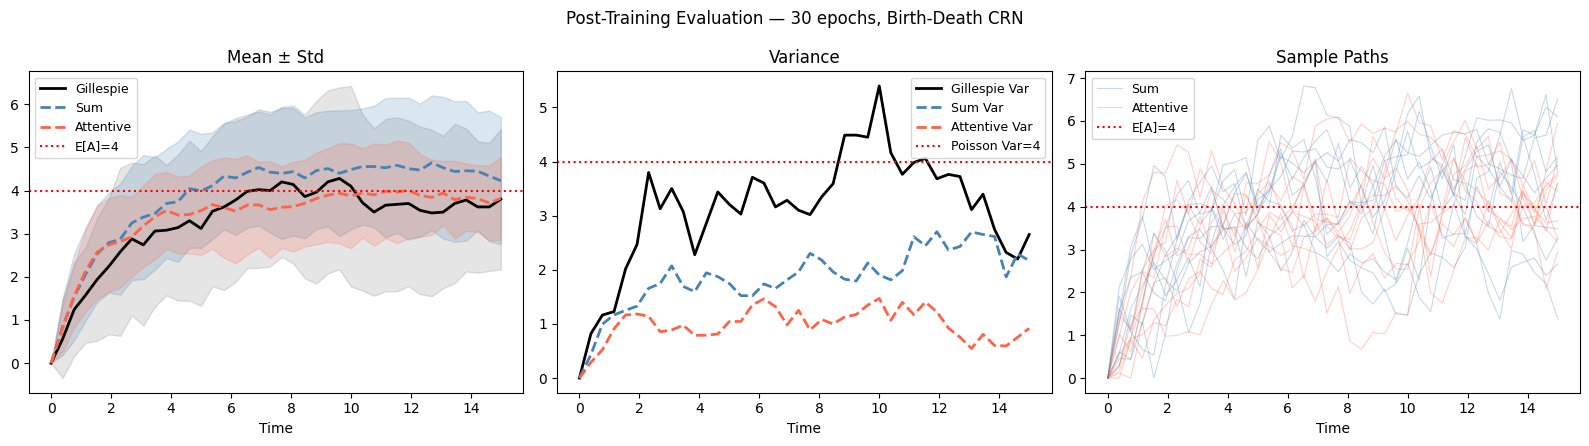

Run 1 — Sum
  Mean MSE:    0.4049
  Var MSE:     2.2519
  Final mean:  4.46  (analytical: 4)
  Final var:   2.39   (analytical: 4)
  Mean SDE std:1.335  OK — nonzero diffusion

Run 2 — Attentive
  Mean MSE:    0.1099
  Var MSE:     5.3392
  Final mean:  3.86  (analytical: 4)
  Final var:   0.85   (analytical: 4)
  Mean SDE std:0.965  OK — nonzero diffusion


In [9]:
from crn_surrogate.simulator.sde_solver import EulerMaruyamaSolver

eval_init = torch.tensor([0.0])
eval_t    = torch.linspace(0.0, T_MAX, N_GRID)
K_EVAL    = 50
M_EVAL    = 50
true_mean = 2.0 / 0.5  # k_birth / k_death

# ── Gillespie ground truth ─────────────────────────────────────────────────────
ssa_trajs = []
for _ in range(M_EVAL):
    r = ssa.simulate(
        stoichiometry=crn.stoichiometry_matrix,
        propensity_fn=crn.evaluate_propensities,
        initial_state=eval_init.clone(),
        t_max=T_MAX,
    )
    ssa_trajs.append(interpolate_to_grid(r.times, r.states, eval_t))
ssa_trajs = torch.stack(ssa_trajs)  # (M_EVAL, N_GRID, 1)

# ── SDE evaluation ─────────────────────────────────────────────────────────────
def eval_sde(encoder, sde, model_config) -> torch.Tensor:
    """Run K_EVAL SDE trajectories and return (K_EVAL, N_GRID, n_species)."""
    solver = EulerMaruyamaSolver(model_config.sde)
    encoder.eval(); sde.eval()
    with torch.no_grad():
        ctx = encoder(crn_repr, eval_init)
        return torch.stack([
            solver.solve(sde, eval_init.clone(), ctx, eval_t, dt=0.1).states
            for _ in range(K_EVAL)
        ])

sde_trajs_sum = eval_sde(encoder_sum, sde_sum, model_config_sum)
sde_trajs_att = eval_sde(encoder_att, sde_att, model_config_att)
print(f'Gillespie: {ssa_trajs.shape} | SDE sum: {sde_trajs_sum.shape} | SDE att: {sde_trajs_att.shape}')

# ── Statistics helper ──────────────────────────────────────────────────────────
def stats(trajs):  # (K, T, 1) → (mean, std) over K
    t0 = trajs[:, :, 0]
    return t0.mean(dim=0).numpy(), t0.std(dim=0).numpy()

ssa_mean, ssa_std = stats(ssa_trajs)
sum_mean, sum_std = stats(sde_trajs_sum)
att_mean, att_std = stats(sde_trajs_att)
t = eval_t.numpy()

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(t, ssa_mean, 'k-', lw=2, label='Gillespie')
ax.fill_between(t, ssa_mean - ssa_std, ssa_mean + ssa_std, alpha=0.10, color='black')
ax.plot(t, sum_mean, '--', color='steelblue', lw=2, label='Sum')
ax.fill_between(t, sum_mean - sum_std, sum_mean + sum_std, alpha=0.20, color='steelblue')
ax.plot(t, att_mean, '--', color='tomato', lw=2, label='Attentive')
ax.fill_between(t, att_mean - att_std, att_mean + att_std, alpha=0.20, color='tomato')
ax.axhline(true_mean, color='red', linestyle=':', lw=1.5, label=f'E[A]={true_mean:.0f}')
ax.set_title('Mean ± Std'); ax.set_xlabel('Time'); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(t, ssa_std**2, 'k-', lw=2, label='Gillespie Var')
ax.plot(t, sum_std**2, '--', color='steelblue', lw=2, label='Sum Var')
ax.plot(t, att_std**2, '--', color='tomato', lw=2, label='Attentive Var')
ax.axhline(true_mean, color='red', linestyle=':', lw=1.5, label=f'Poisson Var={true_mean:.0f}')
ax.set_title('Variance'); ax.set_xlabel('Time'); ax.legend(fontsize=9)

ax = axes[2]
for k in range(min(10, K_EVAL)):
    ax.plot(t, sde_trajs_sum[k, :, 0].numpy(), alpha=0.3, lw=0.8, color='steelblue',
            label='Sum' if k == 0 else '')
    ax.plot(t, sde_trajs_att[k, :, 0].numpy(), alpha=0.3, lw=0.8, color='tomato',
            label='Attentive' if k == 0 else '')
ax.axhline(true_mean, color='red', linestyle=':', lw=1.5, label=f'E[A]={true_mean:.0f}')
ax.set_title('Sample Paths'); ax.set_xlabel('Time'); ax.legend(fontsize=9)

plt.suptitle(f'Post-Training Evaluation — {train_config_sum.max_epochs} epochs, Birth-Death CRN', fontsize=12)
plt.tight_layout(); plt.show()

# ── Metrics ────────────────────────────────────────────────────────────────────
def summarise(label: str, trajs: torch.Tensor) -> None:
    sde_m, sde_s = stats(trajs)
    mean_mse = float(((torch.tensor(sde_m) - torch.tensor(ssa_mean))**2).mean())
    var_mse  = float(((torch.tensor(sde_s**2) - torch.tensor(ssa_std**2))**2).mean())
    final_mean = float(trajs[:, -10:, 0].mean())
    final_var  = float(trajs[:, -10:, 0].var())
    sde_cv = float(trajs[:, :, 0].std(dim=0).mean())
    print(f'  Mean MSE:    {mean_mse:.4f}')
    print(f'  Var MSE:     {var_mse:.4f}')
    print(f'  Final mean:  {final_mean:.2f}  (analytical: {true_mean:.0f})')
    print(f'  Final var:   {final_var:.2f}   (analytical: {true_mean:.0f})')
    print(f'  Mean SDE std:{sde_cv:.3f}  {"OK — nonzero diffusion" if sde_cv >= 0.1 else "WARNING — check diffusion"}')

print('=' * 48)
print('Run 1 — Sum')
summarise('sum', sde_trajs_sum)
print()
print('Run 2 — Attentive')
summarise('attentive', sde_trajs_att)
print('=' * 48)